In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from neuralhydrology.evaluation.metrics import calculate_metrics

from scipy import signal
from neuralhydrology.datautils import utils
from neuralhydrology.evaluation.metrics import _validate_inputs, _mask_valid

In [2]:
# ------------------- Paths -------------------
RUN_DIR = Path("../runs")

ensemble_metrics_dir=Path("./ensemble_peak_metrics")
ensemble_metrics_dir.mkdir(exist_ok=True)

In [3]:
# run_pattern = "precip_prcp_chirps_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_seed_*"
run_pattern = "precip_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"


matched_paths = sorted(RUN_DIR.glob(f"{run_pattern}/test/model_epoch030/test_results.p"))
print(f"Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")

Found 8 runs: ['precip_prcp_gauge_mm_day_seed_111_2202_195308', 'precip_prcp_gauge_mm_day_seed_222_2202_195846', 'precip_prcp_gauge_mm_day_seed_333_2202_200424', 'precip_prcp_gauge_mm_day_seed_444_2202_201003', 'precip_prcp_gauge_mm_day_seed_555_2302_075038', 'precip_prcp_gauge_mm_day_seed_666_2302_075627', 'precip_prcp_gauge_mm_day_seed_777_2302_080217', 'precip_prcp_gauge_mm_day_seed_888_2302_080806']


In [4]:
# Load all runs
all_runs_data = []
for file_path in matched_paths:
    with open(file_path, "rb") as f:
        all_runs_data.append(pickle.load(f))

# Average the simulated flows across seeds, per basin
ensemble_data = {}

for basin_id in all_runs_data[0].keys():
    # Stack simulated flows from all seeds: shape (n_seeds, n_timesteps, time_step)
    sims = np.stack([
        run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values #['QObs(mm/d)_sim'].values 
        for run in all_runs_data
    ], axis=0)
    
    mean_sim = np.mean(sims, axis=0)  # Average across seeds
    
    # Copy structure from first run, replace sim with ensemble mean
    xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
    xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim #['QObs(mm/d)_sim'].values[:] = mean_sim #
    
    ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}

ensemble_data

{'CAMELS_UY_10': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 2009-10-01 ... 2019-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 6.151 5.395 ... 0.2979 0.2661
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.852 0.8052 ... 1.01 0.8188}},
 'CAMELS_UY_11': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 2009-10-01 ... 2019-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.4463 0.8222 ... 0.6856
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.6859 1.554 ... 0.5787 0.5757}},
 'CAMELS_UY_15': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date      

In [5]:
def custom_mean_peak_timing(obs, sim, window=None, resolution='1D', datetime_coord=None, distance=100):
    _validate_inputs(obs, sim)
    obs, sim = _mask_valid(obs, sim)

    peaks, _ = signal.find_peaks(obs.values, distance=distance, prominence=np.std(obs.values))

    if datetime_coord is None:
        datetime_coord = utils.infer_datetime_coord(obs)
    if window is None:
        window = max(int(utils.get_frequency_factor('12h', resolution)), 3)

    timing_errors = []
    for idx in peaks:
        if (idx - window < 0) or (idx + window >= len(obs)) or (
            pd.date_range(obs[idx - window][datetime_coord].values,
                          obs[idx + window][datetime_coord].values,
                          freq=resolution).size != 2 * window + 1):
            continue

        if (sim[idx] > sim[idx - 1]) and (sim[idx] > sim[idx + 1]):
            peak_sim = sim[idx]
        else:
            values = sim[idx - window:idx + window + 1]
            peak_sim = values[values.argmax()]

        peak_obs = obs[idx]
        delta = peak_obs.coords[datetime_coord] - peak_sim.coords[datetime_coord]
        timing_errors.append(np.abs(delta.values / pd.to_timedelta(resolution)))

    return np.mean(timing_errors) if len(timing_errors) > 0 else np.nan


def custom_missed_peaks(obs, sim, window=None, resolution='1D', percentile=80, datetime_coord=None, distance=30):
    _validate_inputs(obs, sim)
    obs, sim = _mask_valid(obs, sim)

    min_obs_height = np.percentile(obs.values, percentile)
    min_sim_height = np.percentile(sim.values, percentile)

    peaks_obs_times, _ = signal.find_peaks(obs, distance=distance, height=min_obs_height)
    peaks_sim_times, _ = signal.find_peaks(sim, distance=distance, height=min_sim_height)

    if len(peaks_obs_times) == 0:
        return 0.

    if datetime_coord is None:
        datetime_coord = utils.infer_datetime_coord(obs)
    if window is None:
        window = max(int(utils.get_frequency_factor('12h', resolution)), 1)

    missed_events = 0
    for idx in peaks_obs_times:
        if (idx - window < 0) or (idx + window >= len(obs)) or (
            pd.date_range(obs[idx - window][datetime_coord].values,
                          obs[idx + window][datetime_coord].values,
                          freq=resolution).size != 2 * window + 1):
            continue

        nearby_peak_sim_index = np.where(np.abs(peaks_sim_times - idx) <= window)[0]
        if len(nearby_peak_sim_index) == 0:
            missed_events += 1

    return missed_events / len(peaks_obs_times)

In [6]:
PEAK_TIMING_DISTANCE = 50
MISSED_PEAKS_DISTANCE = 15
WINDOW = 5

In [7]:
all_metrics = {}
for basin_id, basin_data in ensemble_data.items():
    xr_ds = basin_data['1D']['xr'].isel(time_step=0)
    
    obs = xr_ds['QObs_mm_d_obs']
    sim = xr_ds['QObs_mm_d_sim']
    
    if obs.isnull().all() or sim.isnull().all():
        print(f"Skipping {basin_id} — all observed/simulated values are NaN")
        continue
    
    all_metrics[basin_id] = {
        'Peak-Timing': custom_mean_peak_timing(obs, sim, window=WINDOW, distance=PEAK_TIMING_DISTANCE, resolution="1D", datetime_coord="date"),
        'Missed-Peaks': custom_missed_peaks(obs, sim, window=WINDOW, distance=MISSED_PEAKS_DISTANCE, resolution="1D", datetime_coord="date")
    }

df_metrics = pd.DataFrame(all_metrics).T
df_metrics.index.name = 'basin_id'
df_metrics

Skipping CAMELS_UY_15 — all observed/simulated values are NaN


,Peak-Timing,Missed-Peaks
basin_id,,
CAMELS_UY_10,2.125000,0.283019
CAMELS_UY_11,0.666667,0.270270
CAMELS_UY_16,0.454545,0.277778
CAMELS_UY_2,2.107143,0.543860
CAMELS_UY_3,1.026316,0.246377
CAMELS_UY_5,0.892857,0.362319
CAMELS_UY_6,1.387097,0.317460
CAMELS_UY_7,1.133333,0.246377
CAMELS_UY_8,1.033333,0.229730


# Boxplots

/tmp/ipykernel_474225/3834023035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timing_data, labels=labels)
/tmp/ipykernel_474225/3834023035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(missed_data, labels=labels)


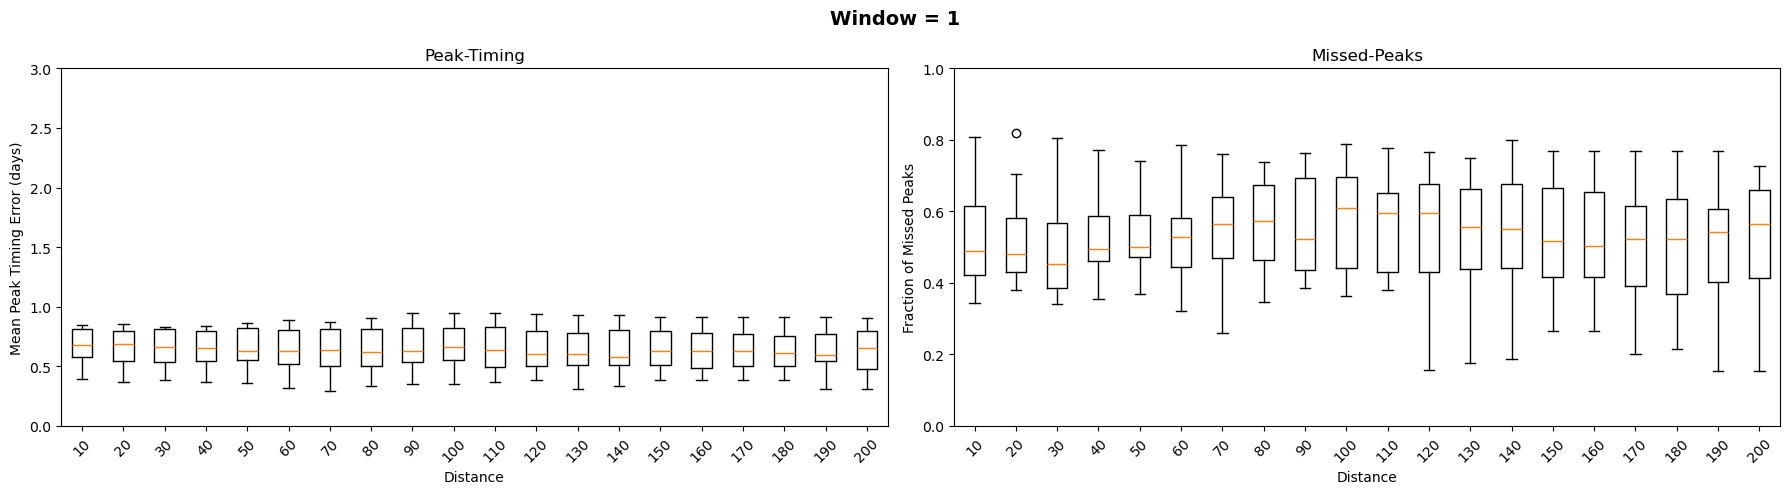

/tmp/ipykernel_474225/3834023035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timing_data, labels=labels)
/tmp/ipykernel_474225/3834023035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(missed_data, labels=labels)


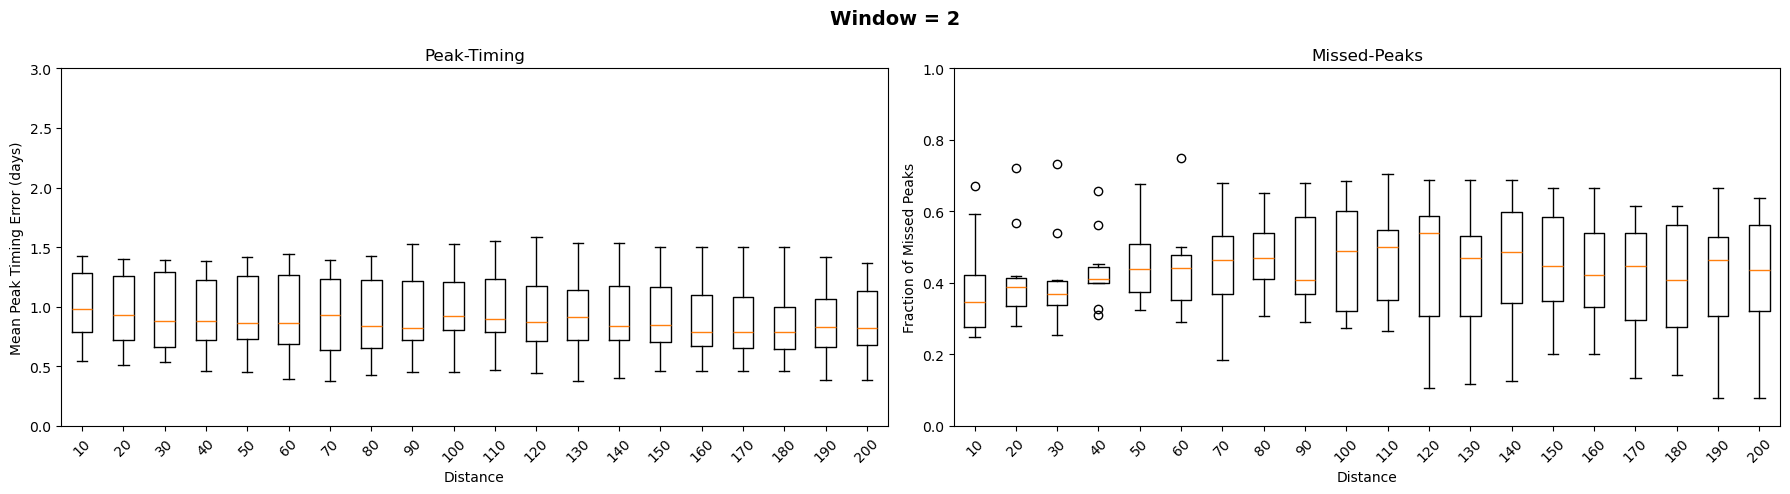

/tmp/ipykernel_474225/3834023035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timing_data, labels=labels)
/tmp/ipykernel_474225/3834023035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(missed_data, labels=labels)


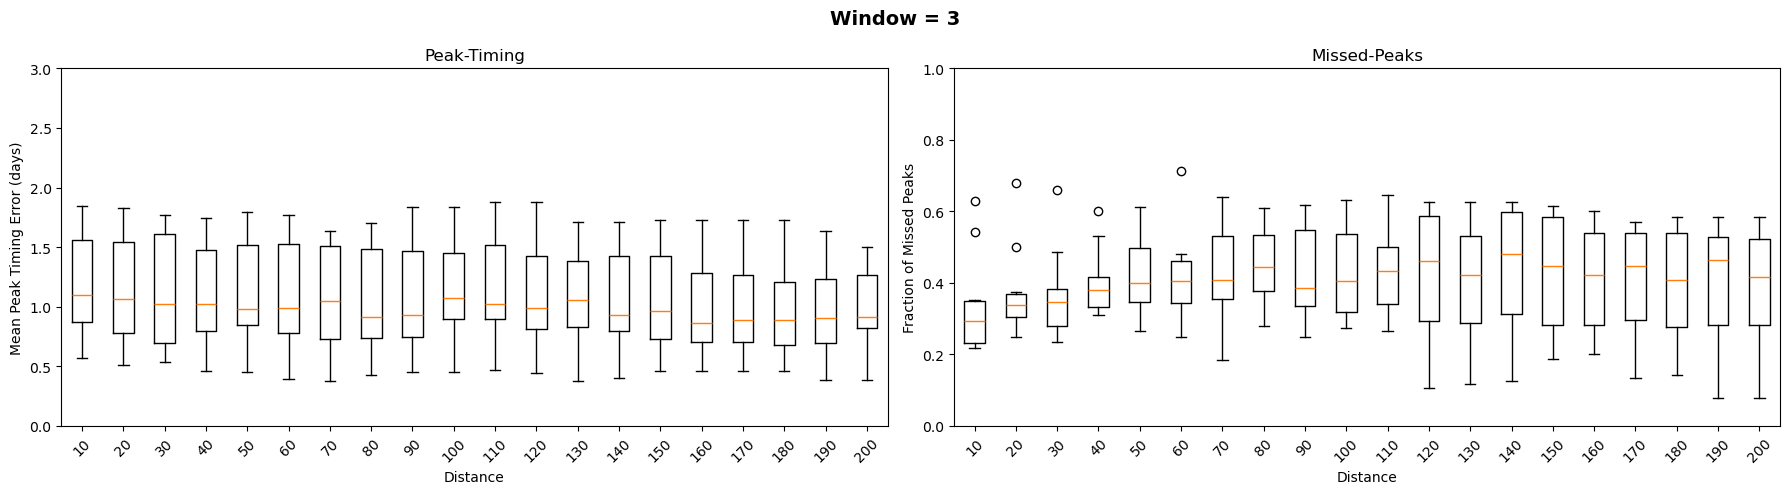

/tmp/ipykernel_474225/3834023035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timing_data, labels=labels)
/tmp/ipykernel_474225/3834023035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(missed_data, labels=labels)


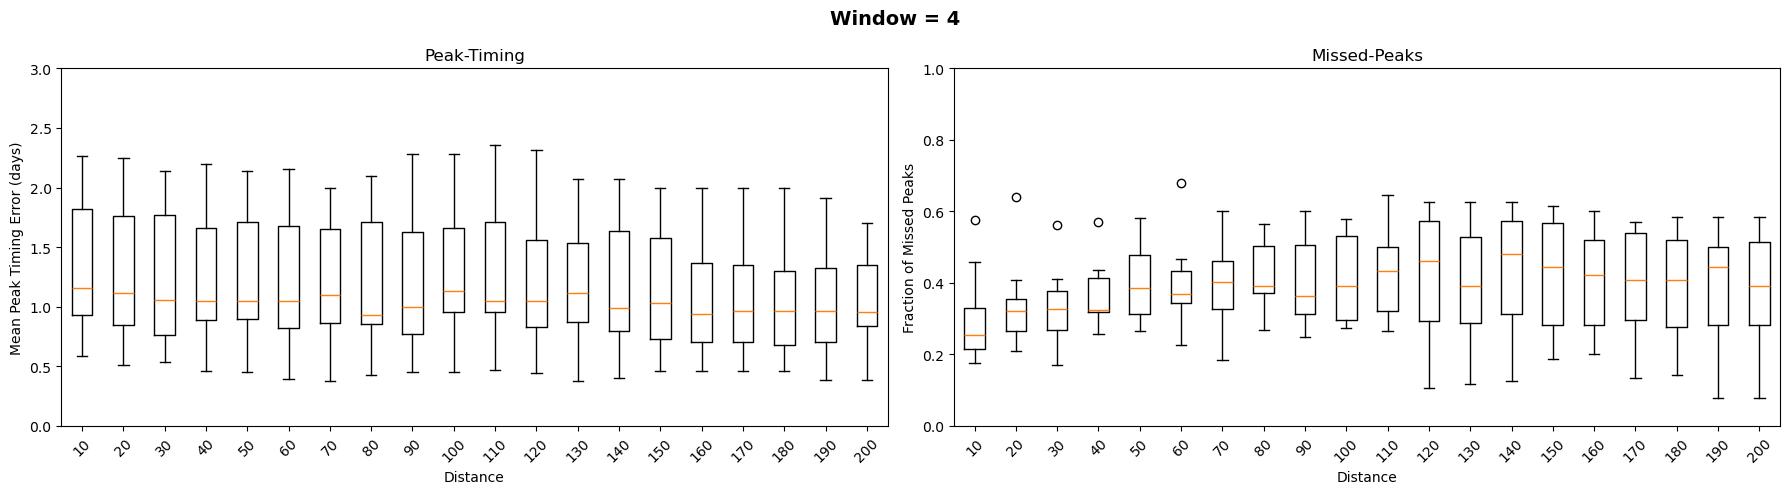

/tmp/ipykernel_474225/3834023035.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timing_data, labels=labels)
/tmp/ipykernel_474225/3834023035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(missed_data, labels=labels)


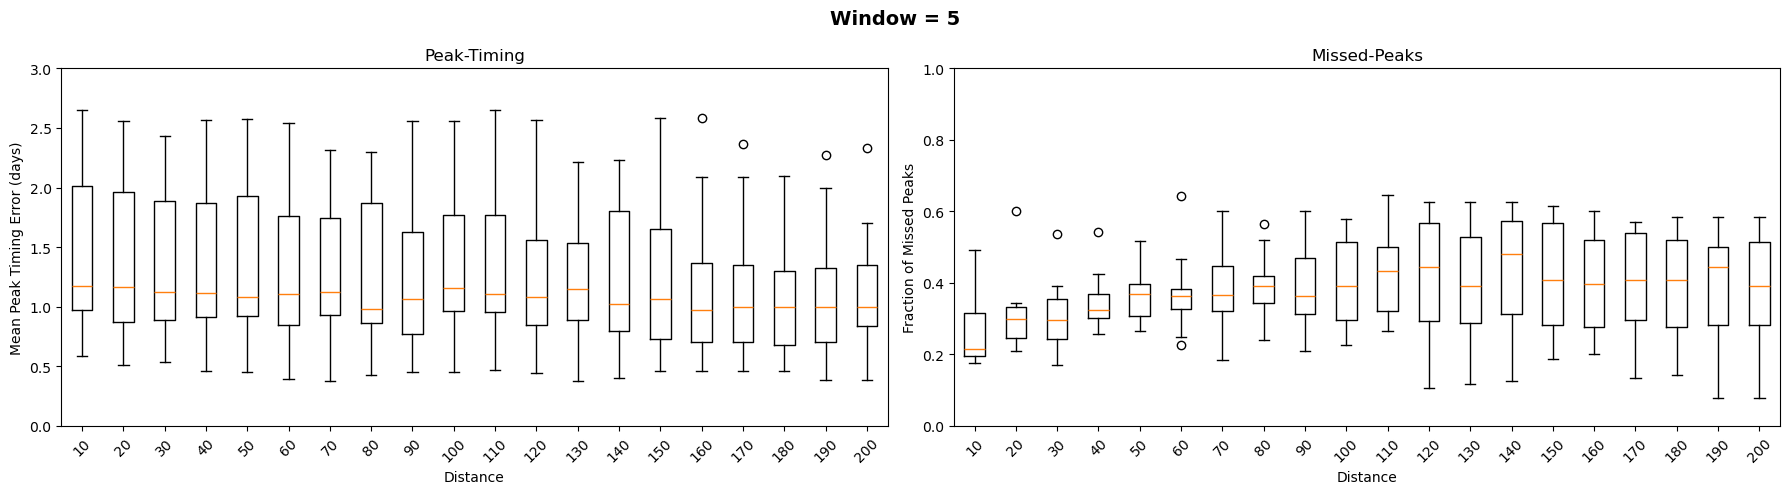

In [8]:
windows = [1, 2, 3, 4, 5]
distances = range(10, 210, 10)

for window in windows:
    # Collect results: {distance: {basin_id: value}}
    results_timing = {d: {} for d in distances}
    results_missed = {d: {} for d in distances}

    for distance in distances:
        for basin_id, basin_data in ensemble_data.items():
            xr_ds = basin_data['1D']['xr'].isel(time_step=0)
            obs = xr_ds['QObs_mm_d_obs']
            sim = xr_ds['QObs_mm_d_sim']

            if obs.isnull().all() or sim.isnull().all():
                continue

            results_timing[distance][basin_id] = custom_mean_peak_timing(
                obs, sim, window=window, distance=distance, resolution="1D", datetime_coord="date"
            )
            results_missed[distance][basin_id] = custom_missed_peaks(
                obs, sim, window=window, distance=distance, resolution="1D", datetime_coord="date"
            )

    # Build data for boxplots
    timing_data = [list(results_timing[d].values()) for d in distances]
    missed_data = [list(results_missed[d].values()) for d in distances]
    labels = [str(d) for d in distances]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f'Window = {window}', fontsize=14, fontweight='bold')

    ax1.boxplot(timing_data, labels=labels)
    ax1.set_title('Peak-Timing')
    ax1.set_xlabel('Distance')
    ax1.set_ylabel('Mean Peak Timing Error (days)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, 3)

    ax2.boxplot(missed_data, labels=labels)
    ax2.set_title('Missed-Peaks')
    ax2.set_xlabel('Distance')
    ax2.set_ylabel('Fraction of Missed Peaks')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

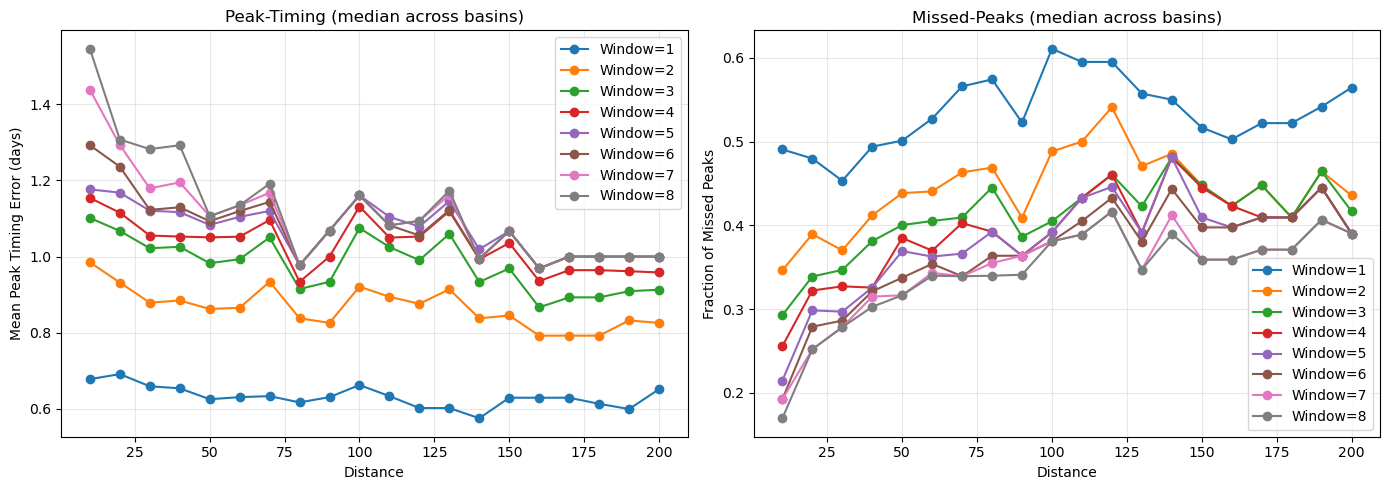

In [9]:
windows = [1, 2, 3, 4, 5, 6, 7, 8]
distances = list(range(10, 210, 10))

# Store median per window per distance
timing_medians = {w: [] for w in windows}
missed_medians = {w: [] for w in windows}

for window in windows:
    for distance in distances:
        timing_vals = []
        missed_vals = []

        for basin_id, basin_data in ensemble_data.items():
            xr_ds = basin_data['1D']['xr'].isel(time_step=0)
            obs = xr_ds['QObs_mm_d_obs']
            sim = xr_ds['QObs_mm_d_sim']

            if obs.isnull().all() or sim.isnull().all():
                continue

            timing_vals.append(custom_mean_peak_timing(
                obs, sim, window=window, distance=distance, resolution="1D", datetime_coord="date"
            ))
            missed_vals.append(custom_missed_peaks(
                obs, sim, window=window, distance=distance, resolution="1D", datetime_coord="date"
            ))

        timing_medians[window].append(np.nanmedian(timing_vals))
        missed_medians[window].append(np.nanmedian(missed_vals))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for window in windows:
    ax1.plot(distances, timing_medians[window], marker='o', label=f'Window={window}')
    ax2.plot(distances, missed_medians[window], marker='o', label=f'Window={window}')

ax1.set_title('Peak-Timing (median across basins)')
ax1.set_xlabel('Distance')
ax1.set_ylabel('Mean Peak Timing Error (days)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('Missed-Peaks (median across basins)')
ax2.set_xlabel('Distance')
ax2.set_ylabel('Fraction of Missed Peaks')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()